# 04 Demo: the quantity intent counts animal legs

**Question.** How does the quantity intent count the legs of an animal, and does it see the leg
that the edited image adds?

**Why.** Every vision-language model that VLMBias tested gives the normal number of legs for the
species on the edited image. The legs counter counts regions in code, so it must see the extra
leg.

**Approach.** The full demo harness (`.env.demo`, classifier `Qwen/Qwen2.5-7B-Instruct`) answers
"How many legs does this animal have?" on three pairs of the VLMBias linear-probing split (two species with four legs, one bird with two), at
768 px: each an original and its edited image. For each answer, the boxes of the animal
(GroundingDINO) and of the legs that remain after the last step (SAM 3) are drawn on the image.

**Prediction.** The classifier chooses `quantity`, and the selector chooses the `legs` counter.
The edited count is higher than the original count on most pairs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import demo
import runs

DATA = runs.data_dir()
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

In [2]:
harness = demo.demo_harness()
QUESTION = "How many legs does this animal have?"

animals = pd.read_parquet(DATA / "train-animals.parquet")
at_768 = animals[animals["pixel"] == 768].reset_index(drop=True)
originals = at_768[at_768["image_type"] == "original"].reset_index(drop=True)
edited = at_768[at_768["image_type"] == "edited"].reset_index(drop=True)
print("pairs at 768 px:", len(originals), len(edited))

/Users/ridzuan5757/Documents/workspace/intent-harness-009-demo-notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 339/339 [00:00<00:00, 6935.81it/s]

pairs at 768 px: 366 366


Three pairs of different species. The original and the edited image of a pair are next to each
other in the table, so the pair is found from the original's file name.

In [3]:
species = ["Raccoon", "Polar Bear", "Bald Eagle"]
pairs = []
for name in species:
    original = originals[originals["name"] == name].iloc[0]
    stem = Path(original["image_path"]).stem.replace("_768", "")
    match = edited[edited["image_path"].str.contains(f"/{stem}/")].iloc[0]
    pairs.append((original, match))
for original, match in pairs:
    print(original["name"], "|", original["image_path"], "|", match["image_path"])

Raccoon | linear_probing_code/linear_probing_dataset/generated_images/Raccoon/originals/raccoon_1_768.png | linear_probing_code/linear_probing_dataset/generated_images/Raccoon/edited/raccoon_1/raccoon_1_edited_1_768.png
Polar Bear | linear_probing_code/linear_probing_dataset/generated_images/Polar Bear/originals/polar_bear_1_768.png | linear_probing_code/linear_probing_dataset/generated_images/Polar Bear/edited/polar_bear_1/polar_bear_1_edited_2_768.png
Bald Eagle | linear_probing_code/linear_probing_dataset/generated_images/Bald Eagle/originals/bald_eagle_2_768.png | linear_probing_code/linear_probing_dataset/generated_images/Bald Eagle/edited/bald_eagle_2/bald_eagle_2_edited_0_768.png


## 1. The answers and the regions

Red: the animal box. Green: each leg region that remains after `remove_duplicate_regions`.

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Loading weights:  68%|██████▊   | 664/978 [00:00<00:00, 6604.73it/s]

Loading weights: 100%|██████████| 978/978 [00:00<00:00, 8091.07it/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading weights:  44%|████▎     | 640/1468 [00:00<00:00, 6398.02it/s]

Loading weights:  87%|████████▋ | 1280/1468 [00:00<00:00, 6274.42it/s]

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 7082.15it/s]

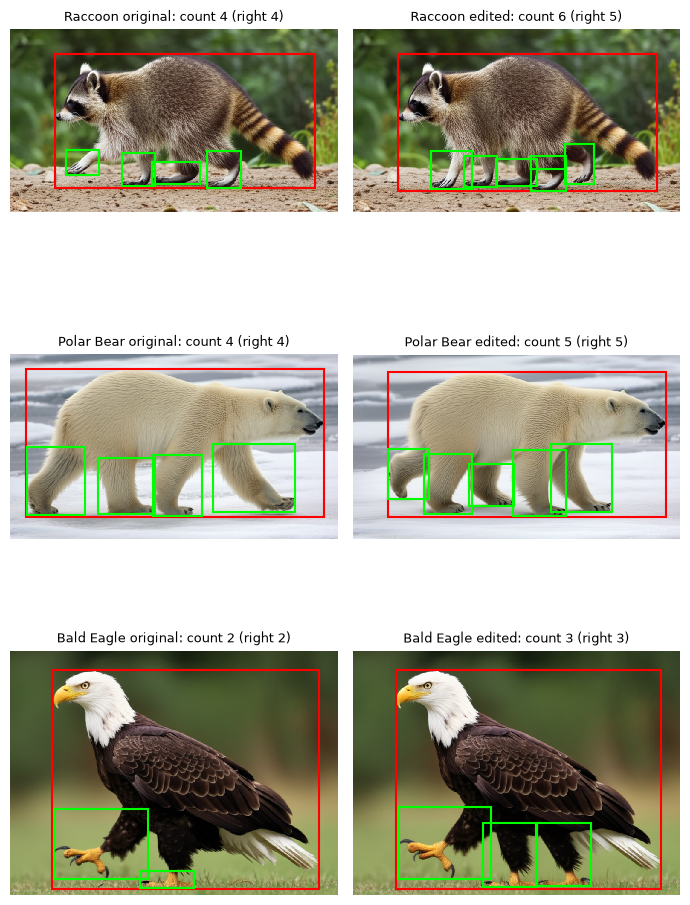

In [4]:
import matplotlib.patches as patches


def draw_box(axis, box, size, colour):
    """`box` is [x1, y1, x2, y2] in image fractions; `size` is the image (width, height)."""
    width, height = size
    x0, y0, x1, y1 = box[0] * width, box[1] * height, box[2] * width, box[3] * height
    axis.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=colour, linewidth=1.5))


answers = []
figure, axes = plt.subplots(len(pairs), 2, figsize=(7, 3.5 * len(pairs)), dpi=60)
for row, (original, match) in enumerate(pairs):
    for column, item in enumerate([original, match]):
        image = Image.open(DATA / "train-animals" / item["image_path"]).convert("RGB")
        answer = harness.answer(image, QUESTION)
        answers.append((item, answer))
        axis = axes[row][column]
        axis.imshow(image, interpolation="nearest")
        for step in answer.trace:
            if step.tool == "best_box" and step.output is not None:
                draw_box(axis, step.output, image.size, "red")
            if step.tool == "remove_duplicate_regions":
                for region in step.output:
                    draw_box(axis, region["box"], image.size, "lime")
        axis.set_title(f"{item['name']} {item['image_type']}: count {answer.value} (right {item['ground_truth']})", fontsize=9)
        axis.axis("off")
plt.tight_layout()
plt.show()

In [5]:
rows = []
for item, answer in answers:
    rows.append({
        "animal": item["name"],
        "image": item["image_type"],
        "intent": answer.intent,
        "confidence": round(answer.confidence, 3),
        "pipeline": answer.pipeline,
        "count": answer.value,
        "right count": int(item["ground_truth"]),
        "right": answer.value == int(item["ground_truth"]),
    })
pd.DataFrame(rows)

,animal,image,intent,confidence,pipeline,count,right count,right
0,Raccoon,original,quantity,1.0,legs,4,4,True
1,Raccoon,edited,quantity,1.0,legs,6,5,False
2,Polar Bear,original,quantity,1.0,legs,4,4,True
3,Polar Bear,edited,quantity,1.0,legs,5,5,True
4,Bald Eagle,original,quantity,1.0,legs,2,2,True
5,Bald Eagle,edited,quantity,1.0,legs,3,3,True


## 2. The trace of one image

The edited image of the first pair. The selector is a tool, so its choice is the first step.
Then the legs counter calls its four tools. The count is the number of regions in the output of
the last step.

In [6]:
item, answer = answers[1]
demo.trace_table(answer)

,step,tool,inputs,output,ok
0,1,select_counter,"image=image 768x429, question='How many legs does this animal have?'",'legs',True
1,2,best_box,"image=image 768x429, query='animal'","[0.13764050602912903, 0.13543483316203653, 0.930087327957...",True
2,3,segment_concept,"image=image 768x429, concept='leg', min_score=0.0100",list of 173,True
3,4,keep_smaller_regions,"regions=list of 173, reference_box=[0.13764050602912903, 0.1354348331620...,...",list of 150,True
4,5,remove_duplicate_regions,"regions=list of 150, threshold=0.4800, nested=True",list of 6,True


In [7]:
rows = []
for step in answer.trace:
    if step.tool in ("segment_concept", "keep_smaller_regions", "remove_duplicate_regions"):
        rows.append({"tool": step.tool, "regions out": len(step.output)})
pd.DataFrame(rows)

,tool,regions out
0,segment_concept,173
1,keep_smaller_regions,150
2,remove_duplicate_regions,6


## Reading the result

(to be written)

## Conclusion

(to be written)